In [1]:
import pandas as pd
import numpy as np
n=10
df = pd.read_csv(f't2_joint_distribution_n{n}.csv')
m_star = 17
t_star = 20

df = df.sort_values(by=['Count'], ascending=False)
#print(df.head(20))s

filtered_df = df[(df['Edges'] == m_star) & (df['Triangles'] == t_star)]

print(filtered_df.head(10))

      Edges  Triangles  Triangle Squares  Count
1313     17         20               600  78750


In [2]:
exact_dist = {}
for _, row in df.iterrows():
    m = row['Edges']
    t = row['Triangles']
    t2 = row['Triangle Squares']
    count = row['Count']
    exact_dist[(m, t, t2)] = count

In [21]:
import numpy as np

import pandas as pd

import matplotlib.pyplot as plt

from scipy.optimize import minimize

from scipy.stats import norm, multivariate_normal


def compute_moments(theta, df):

    log_w = -theta[0] * df['t'] - theta[1] * df['t2'] + np.log(df['count'])

    p = np.exp(log_w - np.max(log_w))

    p /= np.sum(p)

   

    Et, Et2 = np.sum(p * df['t']), np.sum(p * df['t2'])

    var_t = np.sum(p * (df['t'] - Et)**2)

    var_t2 = np.sum(p * (df['t2'] - Et2)**2)

    cov = np.sum(p * (df['t'] - Et) * (df['t2'] - Et2))

   

    return np.array([Et, Et2]), -np.array([[var_t, cov], [cov, var_t2]])


def nll(theta, df, target_stats):

    target_energy = -theta[0] * target_stats[0] - theta[1] * target_stats[1]

    log_w = -theta[0] * df['t'] - theta[1] * df['t2'] + np.log(df['count'])

    log_Z = np.max(log_w) + np.log(np.sum(np.exp(log_w - np.max(log_w))))

    return -(target_energy - log_Z) 

In [22]:
import matplotlib.pyplot as plt
from scipy.optimize import minimize
def evaluate_and_plot_ergm_scaled(exact_dist, target_m, target_t_raw, target_t2_raw, n, epsilon=0.5):
    # 1. Scale the state space statistics by 1/n
    df = pd.DataFrame([{'t': t / n, 't2': t2 / n, 'count': c} 
                        for (m, t, t2), c in exact_dist.items() if m == target_m])
    
    # Scale the target statistics by 1/ns
    target = np.array([target_t_raw / n, target_t2_raw / n])
    
    # 2. Exact MAP & Hessian Extraction
    res = minimize(nll, x0=[0.0, 0.0], args=(df, target), method='BFGS')
    map_theta = res.x
    _, map_hessian = compute_moments(map_theta, df)
    cov_matrix = np.linalg.inv(-map_hessian)
    
    # 3. Local Diagnostics
    theta_pert = map_theta + np.array([epsilon, -epsilon])
    exp_pert, hess_pert = compute_moments(theta_pert, df)
    
    grad_error = np.linalg.norm((-target + exp_pert) - (map_hessian @ (theta_pert - map_theta)))
    hess_error = np.linalg.norm(hess_pert - map_hessian, ord='fro')
    se_beta = np.sqrt(cov_matrix[1, 1])
    z_beta = map_theta[1] / se_beta
    print(n)
    print(f"MAP Estimate: alpha = {map_theta[0]:.4f}, beta = {map_theta[1]:.4f}")
    print(f"Gradient Error (step={epsilon}): {grad_error:.6e}")
    print(f"Hessian Error: {hess_error:.6e}")
    print(f"Beta Z-Score: {z_beta:.4f} (p < 0.05 if |z| > 1.96)\n")
    

    # 4. 2D Grid Evaluation for Marginalization
    grid_pts = 100
    radius_alpha = max(abs(map_theta[0]), 1.0) * 1.1
    radius_beta = max(abs(map_theta[1]), 1.0) * 1.1
    
    a_grid = np.linspace(map_theta[0] - radius_alpha, map_theta[0] + radius_alpha, grid_pts)
    b_grid = np.linspace(map_theta[1] - radius_beta, map_theta[1] + radius_beta, grid_pts)
    A, B = np.meshgrid(a_grid, b_grid, indexing='ij')
    
    grid_thetas = np.c_[A.ravel(), B.ravel()]
    grid_nll = np.array([nll(theta, df, target) for theta in grid_thetas])
    
    log_post = -grid_nll.reshape(grid_pts, grid_pts)
    log_post -= np.max(log_post)
    post_2d = np.exp(log_post)
    post_2d /= np.sum(post_2d)

    # 5. Visualizations (Beta Marginal Only)
    beta_marginal = np.sum(post_2d, axis=0)
    beta_marginal /= np.sum(beta_marginal)
    
    gauss_marginal = norm.pdf(b_grid, loc=map_theta[1], scale=se_beta)
    gauss_marginal /= np.sum(gauss_marginal)

        # --- Exact Posterior Significance Estimation ---

    # 1. Direct Tail Probability P(beta <= 0)
    # Sum the probability mass where the grid values are less than or equal to 0
    prob_less_than_zero = np.sum(beta_marginal[b_grid <= 0])
    print(f"Exact P(beta <= 0): {prob_less_than_zero:.6e}")

    # 2. 95% Equal-Tail Credible Interval
    # Compute the cumulative distribution function (CDF)
    cdf_beta = np.cumsum(beta_marginal)

    # Find indices corresponding to 2.5% and 97.5% cumulative mass
    lower_bound_idx = np.searchsorted(cdf_beta, 0.025)
    upper_bound_idx = np.searchsorted(cdf_beta, 0.975)

    # Extract the corresponding beta values from the grid
    # (Using min to prevent index out of bounds if the mass is highly concentrated)
    lower_bound = b_grid[min(lower_bound_idx, len(b_grid)-1)]
    upper_bound = b_grid[min(upper_bound_idx, len(b_grid)-1)]

    print(f"Exact 95% Credible Interval: [{lower_bound:.4f}, {upper_bound:.4f}]")
    
    fig, ax = plt.subplots(figsize=(8, 5))
    
    ax.plot(b_grid, beta_marginal, label="Exact Marginal", color='#1f77b4', lw=2)
    ax.plot(b_grid, gauss_marginal, '--', label="Laplace Approx", color='#d62728', lw=2)
    ax.axvline(0, color='black', linestyle=':', alpha=0.5, label='Zero') 
    ax.set_xlabel(rf"$\beta$ (for $t^2/n$)")
    ax.set_ylabel("Probability")
    ax.set_title(r"Posterior of $\beta$")
    ax.legend()
    
    plt.tight_layout()
    plt.show()



    return map_theta, cov_matrix

Target m: 18, t: 9, t2: 117
10
MAP Estimate: alpha = -13.1432, beta = 0.3113
Gradient Error (step=0.5): 4.556958e+01
Hessian Error: 7.257123e+00
Beta Z-Score: 0.4463 (p < 0.05 if |z| > 1.96)

Exact P(beta <= 0): 9.861785e-02
Exact 95% Credible Interval: [-0.1443, 1.1446]


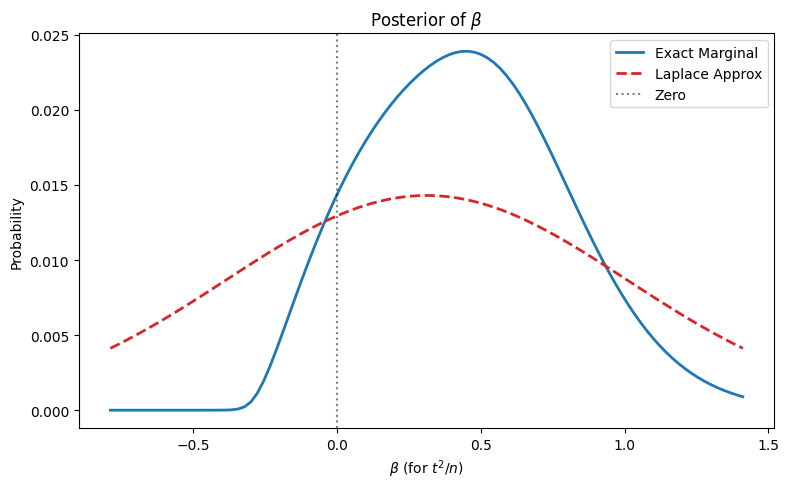

(array([-13.14315305,   0.31125588]),
 array([[373.45297751, -12.95203716],
        [-12.95203716,   0.4863212 ]]))

In [23]:
import networkx as nx
G = nx.erdos_renyi_graph(10, 0.5)
m_star = G.number_of_edges()
t_star = sum(nx.triangles(G).values()) // 3
t2_star = sum([t**2 for t in nx.triangles(G).values()])
print(f"Target m: {m_star}, t: {t_star}, t2: {t2_star}")
evaluate_and_plot_ergm_scaled(exact_dist, target_m=m_star, target_t_raw=t_star, target_t2_raw=t2_star, n=n)

Target m: 20, t: 11, t2: 133
10
MAP Estimate: alpha = -49.1552, beta = 1.7104
Gradient Error (step=0.5): 2.389070e+00
Hessian Error: 1.307695e+01
Beta Z-Score: 1.7511 (p < 0.05 if |z| > 1.96)

Exact P(beta <= 0): 2.005974e-03
Exact 95% Credible Interval: [0.4371, 3.4399]


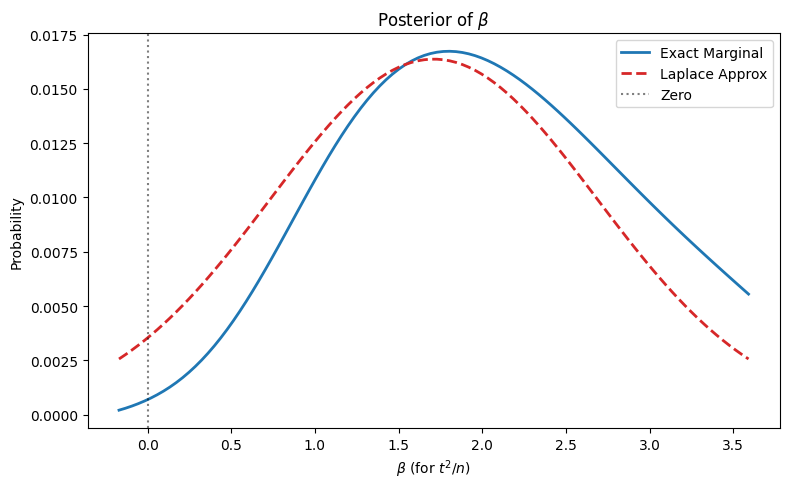

(array([-49.15515009,   1.71042337]),
 array([[552.06903297, -21.61489014],
        [-21.61489014,   0.95403623]]))

In [24]:
G = nx.watts_strogatz_graph(10, 4, 0.3)
m_star = G.number_of_edges()
t_star = sum(nx.triangles(G).values()) // 3
t2_star = sum([t**2 for t in nx.triangles(G).values()])
print(f"Target m: {m_star}, t: {t_star}, t2: {t2_star}")
evaluate_and_plot_ergm_scaled(exact_dist, target_m=m_star, target_t_raw=t_star, target_t2_raw=t2_star, n=n)

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from scipy.stats import norm

def compute_moments_1d(theta, df, tau):
    beta = theta[0]
    # The sufficient statistic S for the single parameter is (t^2 - 2*tau*t)
    S = df['t2'] - 2 * tau * df['t']
    
    log_w = beta * S + np.log(df['count'])
    p = np.exp(log_w - np.max(log_w))
    p /= np.sum(p)
    
    ES = np.sum(p * S)
    var_S = np.sum(p * (S - ES)**2)
    
    return ES, var_S

def nll_1d(theta, df, target_S, tau):
    beta = theta[0]
    S = df['t2'] - 2 * tau * df['t']
    
    target_energy = beta * target_S
    log_w = beta * S + np.log(df['count'])
    log_Z = np.max(log_w) + np.log(np.sum(np.exp(log_w - np.max(log_w))))
    
    return -(target_energy - log_Z)

def evaluate_and_plot_ergm_1d_scaled(exact_dist, target_m, target_t_raw, target_t2_raw, n, epsilon=0.5):
    # 1. Scale the state space statistics by 1/n
    df = pd.DataFrame([{'t': t / n, 't2': t2 / n, 'count': c} 
                        for (m, t, t2), c in exact_dist.items() if m == target_m])
    
    # Calculate tau as the weighted mean of the scaled triangles in the exact distribution
    tau = np.average(df['t'], weights=df['count'])
    
    # Scale the target statistics by 1/n and compute the target sufficient statistic S
    target_t = target_t_raw / n
    target_t2 = target_t2_raw / n
    target_S = target_t2 - 2 * tau * target_t
    
    # 2. Exact MAP & Variance Extraction
    res = minimize(nll_1d, x0=[0.0], args=(df, target_S, tau), method='BFGS')
    map_beta = res.x[0]
    
    exp_S, var_S = compute_moments_1d([map_beta], df, tau)
    cov_beta = 1.0 / var_S if var_S > 0 else np.inf
    se_beta = np.sqrt(cov_beta)
    z_beta = map_beta / se_beta
    
    print(f"n = {n}")
    print(f"Tau (mean of scaled triangles) = {tau:.6f}")
    print(f"MAP Estimate: beta = {map_beta:.4f}")
    print(f"Beta Z-Score: {z_beta:.4f} (p < 0.05 if |z| > 1.96)\n")
    
    # 3. 1D Grid Evaluation for Posterior
    grid_pts = 300
    radius_beta = max(abs(map_beta), 1.0) * 1.5
    
    b_grid = np.linspace(map_beta - radius_beta, map_beta + radius_beta, grid_pts)
    grid_nll = np.array([nll_1d([b], df, target_S, tau) for b in b_grid])
    
    log_post = -grid_nll
    log_post -= np.max(log_post)
    post_1d = np.exp(log_post)
    post_1d /= np.sum(post_1d)
    
    # 4. Visualizations & Inference
    gauss_marginal = norm.pdf(b_grid, loc=map_beta, scale=se_beta)
    gauss_marginal /= np.sum(gauss_marginal)
    
    # Direct Tail Probability P(beta <= 0)
    prob_less_than_zero = np.sum(post_1d[b_grid <= 0])
    print(f"Exact P(beta <= 0): {prob_less_than_zero:.6e}")
    
    # 95% Equal-Tail Credible Interval
    cdf_beta = np.cumsum(post_1d)
    lower_bound_idx = np.searchsorted(cdf_beta, 0.025)
    upper_bound_idx = np.searchsorted(cdf_beta, 0.975)
    
    lower_bound = b_grid[min(lower_bound_idx, len(b_grid)-1)]
    upper_bound = b_grid[min(upper_bound_idx, len(b_grid)-1)]
    print(f"Exact 95% Credible Interval: [{lower_bound:.4f}, {upper_bound:.4f}]")
    
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(b_grid, post_1d, label="Exact Posterior", color='#1f77b4', lw=2)
    ax.plot(b_grid, gauss_marginal, '--', label="Laplace Approx", color='#d62728', lw=2)
    ax.axvline(0, color='black', linestyle=':', alpha=0.5, label='Zero') 
    ax.set_xlabel(rf"$\beta$")
    ax.set_ylabel("Probability")
    ax.set_title(rf"Posterior of $\beta$ (coupled model, $\tau={tau:.4f}$)")
    ax.legend()
    
    plt.tight_layout()
    plt.show()

    return map_beta, cov_beta

Target m: 26, t: 24, t2: 742
n = 10
Tau (mean of scaled triangles) = 2.198732
MAP Estimate: beta = 0.0615
Beta Z-Score: 1.3271 (p < 0.05 if |z| > 1.96)

Exact P(beta <= 0): 1.972991e-01
Exact 95% Credible Interval: [-0.0739, 0.1167]


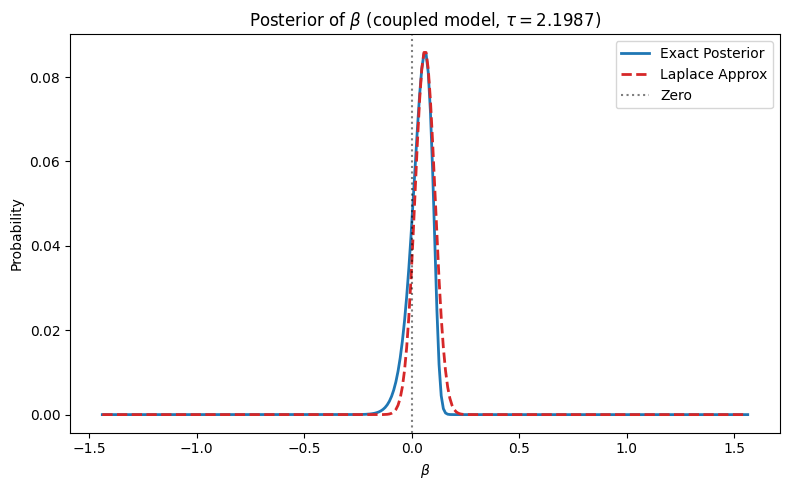

(np.float64(0.06152208169120338), np.float64(0.0021491972486374212))

In [4]:
import networkx as nx
G = nx.erdos_renyi_graph(10, 0.5)
m_star = G.number_of_edges()
t_star = sum(nx.triangles(G).values()) // 3
t2_star = sum([t**2 for t in nx.triangles(G).values()])
print(f"Target m: {m_star}, t: {t_star}, t2: {t2_star}")
evaluate_and_plot_ergm_1d_scaled(exact_dist, target_m=m_star, target_t_raw=t_star, target_t2_raw=t2_star, n=n)

Target m: 20, t: 9, t2: 83
n = 10
Tau (mean of scaled triangles) = 0.964059
MAP Estimate: beta = -0.2500
Beta Z-Score: -0.7897 (p < 0.05 if |z| > 1.96)

Exact P(beta <= 0): 9.153093e-01
Exact 95% Credible Interval: [-1.2082, 0.0961]


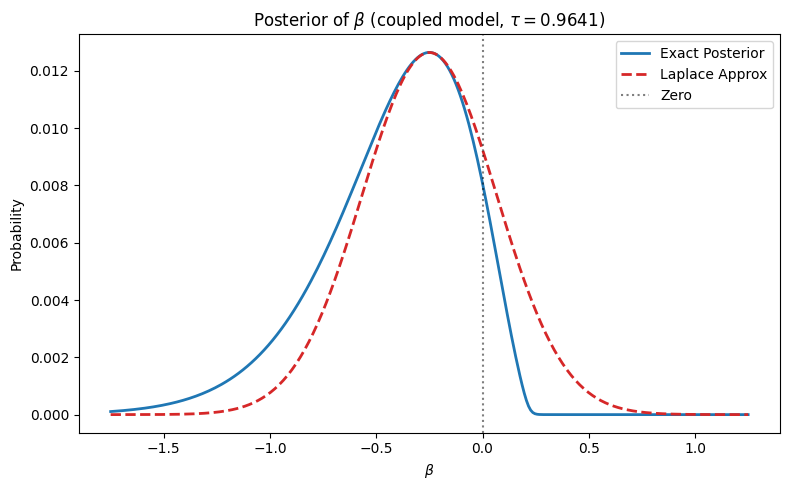

(np.float64(-0.25001952006411227), np.float64(0.10023209290755836))

In [5]:
G = nx.watts_strogatz_graph(10, 4, 0.3)
m_star = G.number_of_edges()
t_star = sum(nx.triangles(G).values()) // 3
t2_star = sum([t**2 for t in nx.triangles(G).values()])
print(f"Target m: {m_star}, t: {t_star}, t2: {t2_star}")
evaluate_and_plot_ergm_1d_scaled(exact_dist, target_m=m_star, target_t_raw=t_star, target_t2_raw=t2_star, n=n)

In [6]:
import networkx as nx
import numpy as np

class graphWithComplement:
    def __init__(self, n, p=None):
        self.n = n
        self.half_of_all_edges = n*(n-1)//4
        if p is None:
            self.graph = nx.empty_graph(n)
            self.complement = nx.complete_graph(n)
        else:
            self.graph = nx.fast_gnp_random_graph(n, p)
            self.complement = nx.complement(self.graph)

        self.node_triangles = np.zeros(n, dtype=int)
        triangles_dict = nx.triangles(self.graph)
        for i in range(n):
            self.node_triangles[i] = triangles_dict[i]

    def get_common_neighbors(self, u, v, m=None):
        """Returns an iterable of common neighbors, optimized for density."""
        if m is None or m < self.half_of_all_edges:
            return set(nx.common_neighbors(self.graph, u, v))
        else:
            not_common = self.complement.adj[u].keys() | self.complement.adj[v].keys()
            return set(self.graph.nodes()) - {u, v} - not_common

    def number_of_common_neighbors(self, u, v, m=None):
        return len(self.get_common_neighbors(u, v, m))

    def get_delta_sum_sq_triangles(self, u, v, is_edge, common_nodes):
        """Calculates the change in sum(t_i^2) if edge (u,v) is toggled."""
        c = len(common_nodes)
        if c == 0:
            return 0
            
        tu = self.node_triangles[u]
        tv = self.node_triangles[v]
        sum_tw = sum(self.node_triangles[w] for w in common_nodes)
        
        if not is_edge:  # Adding an edge
            return 2 * c * (tu + tv + c) + 2 * sum_tw + c
        else:            # Removing an edge
            return -2 * c * (tu + tv - c) - 2 * sum_tw + c

    def add_edge(self, u, v, common_nodes=None):
        if common_nodes is None:
            common_nodes = self.get_common_neighbors(u, v)
            
        c = len(common_nodes)
        self.node_triangles[u] += c
        self.node_triangles[v] += c
        for w in common_nodes:
            self.node_triangles[w] += 1
            
        self.graph.add_edge(u, v)
        self.complement.remove_edge(u, v)

    def remove_edge(self, u, v, common_nodes=None):
        if common_nodes is None:
            common_nodes = self.get_common_neighbors(u, v)
            
        c = len(common_nodes)
        self.node_triangles[u] -= c
        self.node_triangles[v] -= c
        for w in common_nodes:
            self.node_triangles[w] -= 1

        self.graph.remove_edge(u, v)
        self.complement.add_edge(u, v)

    def has_edge(self, u, v):
        return self.graph.has_edge(u, v)


def run_chain_fixed_edges(G, n, alpha, beta, burn_in=100000, sample_size=500000, sample_interval=100):
    m = G.graph.number_of_edges()
    t = np.sum(G.node_triangles) // 3
    t2 = np.sum(G.node_triangles ** 2)

    total_steps = burn_in + sample_size
    samples_t = []
    samples_t2 = []

    for step in range(total_steps):
        if step >= burn_in and (step - burn_in) % 100000 == 0:
            print(f"Sampling step {step - burn_in}/{sample_size}")

        # 1. Select an existing edge to remove
        while True:
            u_r, v_r = np.random.randint(0, n, 2)
            if u_r != v_r and G.has_edge(u_r, v_r): 
                break

        # 2. Select a non-existing edge to add
        while True:
            u_a, v_a = np.random.randint(0, n, 2)
            if u_a != v_a and not G.has_edge(u_a, v_a): 
                break

        # 3. Calculate deltas for removal and apply temporarily
        common_r = G.get_common_neighbors(u_r, v_r, m)
        delta_t2_r = G.get_delta_sum_sq_triangles(u_r, v_r, True, common_r)
        delta_t_r = -len(common_r)
        
        G.remove_edge(u_r, v_r, common_r)

        # 4. Calculate deltas for addition from the intermediate state
        common_a = G.get_common_neighbors(u_a, v_a, m)
        delta_t2_a = G.get_delta_sum_sq_triangles(u_a, v_a, False, common_a)
        delta_t_a = len(common_a)

        # 5. Aggregate total deltas 
        delta_t = delta_t_r + delta_t_a
        delta_t2 = delta_t2_r + delta_t2_a

        # 6. Evaluate Energy difference (Scaled by 1/n)
        delta_energy = (alpha * delta_t + beta * delta_t2) / n
        
        # 7. Metropolis-Hastings check
        if np.log(np.random.uniform()) <= delta_energy:
            # ACCEPT: Keep the new state
            G.add_edge(u_a, v_a, common_a)
            t += delta_t
            t2 += delta_t2
        else:
            # REJECT: Revert the temporary removal
            G.add_edge(u_r, v_r, common_r)

        # 8. Sampling
        if step >= burn_in and (step - burn_in) % sample_interval == 0:
            samples_t.append(t / n)
            samples_t2.append(t2 / n)

    samples_t = np.array(samples_t)
    samples_t2 = np.array(samples_t2)
    
    avg_t_scaled = np.mean(samples_t)
    avg_t2_scaled = np.mean(samples_t2)
    
    return G, avg_t_scaled, avg_t2_scaled, samples_t, samples_t2


def mle_optimize_fixed_edges(G_init, target_t_scaled, target_t2_scaled, n, max_epochs=50):
    alpha, beta = 0.0, 0.0 
    lr_a, lr_b = 0.05, 0.005 
    
    m_a, v_a = 0.0, 0.0
    m_b, v_b = 0.0, 0.0
    b1, b2, eps = 0.9, 0.999, 1e-8
    
    G = G_init
    G_list = []
    
    final_samples_t = None
    final_samples_t2 = None
    
    # --- NEW: History tracking lists ---
    history_alpha, history_beta = [], []
    history_t, history_t2 = [], []
    
    for epoch in range(max_epochs):        
        current_burn = 100000 if epoch < 5 else 50000 
        
        G, avg_t, avg_t2, samp_t, samp_t2 = run_chain_fixed_edges(
            G, n, alpha, beta, 
            burn_in=current_burn, sample_size=500000
        )

        G_list.append(G.graph.copy())
        
        # --- NEW: Record History ---
        history_alpha.append(alpha)
        history_beta.append(beta)
        history_t.append(avg_t)
        history_t2.append(avg_t2)
        
        grad_a = target_t_scaled - avg_t
        grad_b = target_t2_scaled - avg_t2
        
        grad_a = np.clip(grad_a, -50.0, 50.0)
        grad_b = np.clip(grad_b, -500.0, 500.0)
        
        m_a = b1 * m_a + (1 - b1) * grad_a
        v_a = b2 * v_a + (1 - b2) * (grad_a ** 2)
        m_a_hat = m_a / (1 - b1 ** (epoch + 1))
        v_a_hat = v_a / (1 - b2 ** (epoch + 1))
        alpha += lr_a * m_a_hat / (np.sqrt(v_a_hat) + eps)

        m_b = b1 * m_b + (1 - b1) * grad_b
        v_b = b2 * v_b + (1 - b2) * (grad_b ** 2)
        m_b_hat = m_b / (1 - b1 ** (epoch + 1))
        v_b_hat = v_b / (1 - b2 ** (epoch + 1))
        beta += lr_b * m_b_hat / (np.sqrt(v_b_hat) + eps)

        print(f"Epoch {epoch+1}/{max_epochs} | "
              f"Target t/n: {target_t_scaled:.2f}, Avg t/n: {avg_t:.2f} | "
              f"Target t2/n: {target_t2_scaled:.2f}, Avg t2/n: {avg_t2:.2f} | "
              f"Alpha: {alpha:.4f}, Beta: {beta:.4f}")
              
        if epoch == max_epochs - 1:
            final_samples_t = samp_t
            final_samples_t2 = samp_t2

    sample_matrix = np.vstack((final_samples_t, final_samples_t2))
    cov_matrix = np.cov(sample_matrix)
    posterior_cov = np.linalg.inv(cov_matrix)
    
    # --- NEW: Return history block ---
    history = (history_alpha, history_beta, history_t, history_t2)
    return alpha, beta, posterior_cov, G_list, history

def init_custom_graph_from_nx(nx_graph):
    n = nx_graph.number_of_nodes()
    custom_G = graphWithComplement(n)
    for u, v in nx_graph.edges():
        custom_G.add_edge(u, v)
    return custom_G

def fit_watts_strogatz():
    n = 500   
    k = 12      
    p = 0.1    

    print("Generating Target Watts-Strogatz Graph...")
    G_target_nx = nx.watts_strogatz_graph(n, k, p)
    
    target_m = G_target_nx.number_of_edges()
    target_tris_dict = nx.triangles(G_target_nx)
    target_node_triangles = np.array(list(target_tris_dict.values()))
    
    target_t = np.sum(target_node_triangles) // 3
    target_t2 = np.sum(target_node_triangles ** 2)
    
    # Scale targets
    target_t_scaled = target_t / n
    target_t2_scaled = target_t2 / n
    
    print(f"Target Stats -> m: {target_m}, t/n: {target_t_scaled:.2f}, t2/n: {target_t2_scaled:.2f}")

    # --- CHANGED INITIALIZATION HERE ---
    print("\nInitializing starting graph G_init from the Target Graph...")
    G_init = init_custom_graph_from_nx(G_target_nx.copy())

    print("\nStarting MLE Optimization...")
    max_epochs = 50 
    
    fitted_alpha, fitted_beta, posterior_cov, graph_history, history = mle_optimize_fixed_edges(
        G_init=G_init, 
        target_t_scaled=target_t_scaled, 
        target_t2_scaled=target_t2_scaled, 
        n=n, 
        max_epochs=max_epochs
    )
    
    se_alpha = np.sqrt(posterior_cov[0, 0])
    se_beta = np.sqrt(posterior_cov[1, 1])
    
    print(f"\nOptimization Complete.")
    print(f"Final Alpha: {fitted_alpha:.6f} (SE: {se_alpha:.6f})")
    print(f"Final Beta: {fitted_beta:.6f} (SE: {se_beta:.6f})")
    
    return fitted_alpha, fitted_beta, posterior_cov, graph_history, history, G_target_nx

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

def plot_posteriors_and_significance(fitted_alpha, fitted_beta, posterior_cov):
    # 1. Extract variances and standard errors from the posterior covariance matrix
    # posterior_cov[0, 0] is the variance of alpha, posterior_cov[1, 1] is the variance of beta
    se_alpha = np.sqrt(posterior_cov[0, 0])
    se_beta = np.sqrt(posterior_cov[1, 1])
    
    # 2. Calculate Significance Metrics (Laplace Approximation)
    
    # --- Alpha Metrics ---
    z_alpha = fitted_alpha / se_alpha
    p_val_alpha = 2 * (1 - norm.cdf(abs(z_alpha)))
    # Calculate probability of the tail crossing zero
    prob_alpha_zero_tail = norm.cdf(0, loc=fitted_alpha, scale=se_alpha) if fitted_alpha > 0 else (1 - norm.cdf(0, loc=fitted_alpha, scale=se_alpha))
    ci_lower_alpha = fitted_alpha - 1.95996 * se_alpha
    ci_upper_alpha = fitted_alpha + 1.95996 * se_alpha

    # --- Beta Metrics ---
    z_beta = fitted_beta / se_beta
    p_val_beta = 2 * (1 - norm.cdf(abs(z_beta)))
    prob_beta_zero_tail = norm.cdf(0, loc=fitted_beta, scale=se_beta) if fitted_beta > 0 else (1 - norm.cdf(0, loc=fitted_beta, scale=se_beta))
    ci_lower_beta = fitted_beta - 1.95996 * se_beta
    ci_upper_beta = fitted_beta + 1.95996 * se_beta
    
    # Print Alpha Results
    print("--- ALPHA SIGNIFICANCE (LAPLACE APPROXIMATION) ---")
    print(f"Alpha Estimate:  {fitted_alpha:.6f}")
    print(f"Standard Error:  {se_alpha:.6f}")
    print(f"Z-Score:         {z_alpha:.4f}")
    print(f"P-value (2-tail):{p_val_alpha:.6e}")
    tail_label_a = "P(Alpha <= 0)" if fitted_alpha > 0 else "P(Alpha >= 0)"
    print(f"{tail_label_a:<17}: {prob_alpha_zero_tail:.6e}")
    print(f"95% CI:          [{ci_lower_alpha:.6f}, {ci_upper_alpha:.6f}]\n")

    # Print Beta Results
    print("--- BETA SIGNIFICANCE (LAPLACE APPROXIMATION) ---")
    print(f"Beta Estimate:   {fitted_beta:.6f}")
    print(f"Standard Error:  {se_beta:.6f}")
    print(f"Z-Score:         {z_beta:.4f}")
    print(f"P-value (2-tail):{p_val_beta:.6e}")
    tail_label_b = "P(Beta <= 0)" if fitted_beta > 0 else "P(Beta >= 0)"
    print(f"{tail_label_b:<17}: {prob_beta_zero_tail:.6e}")
    print(f"95% CI:          [{ci_lower_beta:.6f}, {ci_upper_beta:.6f}]\n")
    
    # 3. Plot the Gaussian Posterior Approximations
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # --- Plot Alpha ---
    a_grid = np.linspace(fitted_alpha - 4*se_alpha, fitted_alpha + 4*se_alpha, 500)
    gauss_marginal_a = norm.pdf(a_grid, loc=fitted_alpha, scale=se_alpha)
    
    axes[0].plot(a_grid, gauss_marginal_a, '-', label="Laplace Posterior Approx", color='#1f77b4', lw=2)
    axes[0].axvline(0, color='black', linestyle=':', alpha=0.5, label='Zero') 
    axes[0].axvline(fitted_alpha, color='#2ca02c', linestyle='--', alpha=0.8, label='MAP Estimate')
    
    # Shade the tail crossing zero
    if fitted_alpha > 0:
        tail_grid_a = a_grid[a_grid <= 0]
        if len(tail_grid_a) > 0:
            axes[0].fill_between(tail_grid_a, 0, norm.pdf(tail_grid_a, loc=fitted_alpha, scale=se_alpha), color='red', alpha=0.3, label='P(alpha <= 0)')
    else:
        tail_grid_a = a_grid[a_grid >= 0]
        if len(tail_grid_a) > 0:
            axes[0].fill_between(tail_grid_a, 0, norm.pdf(tail_grid_a, loc=fitted_alpha, scale=se_alpha), color='red', alpha=0.3, label='P(alpha >= 0)')

    axes[0].set_xlabel(rf"$\alpha$ (for $t/n$)")
    axes[0].set_ylabel("Probability Density")
    axes[0].set_title(r"Laplace Approximation of $\alpha$ Posterior ($n=500$)")
    axes[0].legend()

    # --- Plot Beta ---
    b_grid = np.linspace(fitted_beta - 4*se_beta, fitted_beta + 4*se_beta, 500)
    gauss_marginal_b = norm.pdf(b_grid, loc=fitted_beta, scale=se_beta)
    
    axes[1].plot(b_grid, gauss_marginal_b, '-', label="Laplace Posterior Approx", color='#d62728', lw=2)
    axes[1].axvline(0, color='black', linestyle=':', alpha=0.5, label='Zero') 
    axes[1].axvline(fitted_beta, color='#2ca02c', linestyle='--', alpha=0.8, label='MAP Estimate')
    
    # Shade the tail crossing zero
    if fitted_beta > 0:
        tail_grid_b = b_grid[b_grid <= 0]
        if len(tail_grid_b) > 0:
            axes[1].fill_between(tail_grid_b, 0, norm.pdf(tail_grid_b, loc=fitted_beta, scale=se_beta), color='red', alpha=0.3, label='P(beta <= 0)')
    else:
        tail_grid_b = b_grid[b_grid >= 0]
        if len(tail_grid_b) > 0:
            axes[1].fill_between(tail_grid_b, 0, norm.pdf(tail_grid_b, loc=fitted_beta, scale=se_beta), color='red', alpha=0.3, label='P(beta >= 0)')

    axes[1].set_xlabel(rf"$\beta$ (for $t_2/n$)")
    axes[1].set_ylabel("Probability Density")
    axes[1].set_title(r"Laplace Approximation of $\beta$ Posterior ($n=500$)")
    axes[1].legend()
    
    plt.tight_layout()
    plt.show()


In [8]:
import matplotlib.pyplot as plt

def plot_optimization_history(history, target_t_scaled, target_t2_scaled):
    history_alpha, history_beta, history_t, history_t2 = history
    epochs = range(1, len(history_alpha) + 1)

    fig, axs = plt.subplots(2, 2, figsize=(14, 10))

    # 1. Parameter Trace (How Alpha and Beta change over time)
    axs[0, 0].plot(epochs, history_alpha, label=r'$\alpha$', color='#1f77b4', lw=2)
    axs[0, 0].plot(epochs, history_beta, label=r'$\beta$', color='#d62728', lw=2)
    axs[0, 0].set_xlabel('Epoch')
    axs[0, 0].set_ylabel('Parameter Value')
    axs[0, 0].set_title('Parameter Trajectory')
    axs[0, 0].legend()

    # 2. Statistics Trace (Log Scale to see massive jumps)
    axs[0, 1].plot(epochs, history_t, label='Avg $t/n$', color='#1f77b4', marker='.')
    axs[0, 1].axhline(target_t_scaled, color='#1f77b4', linestyle='--', alpha=0.6, label='Target $t/n$')
    
    axs[0, 1].plot(epochs, history_t2, label='Avg $t_2/n$', color='#d62728', marker='.')
    axs[0, 1].axhline(target_t2_scaled, color='#d62728', linestyle='--', alpha=0.6, label='Target $t_2/n$')
    
    axs[0, 1].set_yscale('log') # Crucial for seeing degeneracy
    axs[0, 1].set_xlabel('Epoch')
    axs[0, 1].set_ylabel('Statistic Value (Log Scale)')
    axs[0, 1].set_title('Sampled Statistics vs. Target')
    axs[0, 1].legend()

    # 3. Parameter Phase Space (How Alpha and Beta move together)
    axs[1, 0].plot(history_alpha, history_beta, marker='o', markersize=4, color='purple', alpha=0.6, lw=1)
    axs[1, 0].plot(history_alpha[0], history_beta[0], marker='s', color='green', markersize=8, label='Start')
    axs[1, 0].plot(history_alpha[-1], history_beta[-1], marker='X', color='red', markersize=10, label='End')
    axs[1, 0].set_xlabel(r'$\alpha$')
    axs[1, 0].set_ylabel(r'$\beta$')
    axs[1, 0].set_title('Parameter Phase Space')
    axs[1, 0].legend()

    # 4. Statistics Phase Space (The Oscillation Check)
    axs[1, 1].plot(history_t, history_t2, marker='o', markersize=5, color='orange', alpha=0.6, lw=1, label='Sampled States')
    axs[1, 1].scatter(target_t_scaled, target_t2_scaled, color='black', marker='*', s=250, zorder=5, label='Target')
    
    axs[1, 1].set_yscale('log')
    axs[1, 1].set_xscale('log')
    axs[1, 1].set_xlabel('Avg $t/n$ (Log Scale)')
    axs[1, 1].set_ylabel('Avg $t_2/n$ (Log Scale)')
    axs[1, 1].set_title('State Oscillation (Phase Space)')
    axs[1, 1].legend()

    plt.tight_layout()
    plt.show()

# Execution example (assuming 'history' was returned from your fit function):
# target_t_scaled = 10.80  # Replace with your actual target variable
# target_t2_scaled = 1091.77 # Replace with your actual target variable
# plot_optimization_history(history, target_t_scaled, target_t2_scaled)

In [9]:
fitted_alpha, fitted_beta, posterior_cov, graph_history, history, G_target_nx = fit_watts_strogatz()
plot_posteriors_and_significance(fitted_alpha, fitted_beta, posterior_cov)
target_t_scaled = G_target_nx.number_of_edges() / G_target_nx.number_of_nodes()
target_tris_dict = nx.triangles(G_target_nx)
target_node_triangles = np.array(list(target_tris_dict.values()))
target_t2_scaled = np.sum(target_node_triangles ** 2) / G_target_nx.number_of_nodes()
print(f"Target t/n: {target_t_scaled:.2f}, Target t2/n: {target_t2_scaled:.2f}")
plot_optimization_history(history, target_t_scaled, target_t2_scaled)


Generating Target Watts-Strogatz Graph...
Target Stats -> m: 3000, t/n: 10.89, t2/n: 1112.59

Initializing starting graph G_init from the Target Graph...

Starting MLE Optimization...


KeyboardInterrupt: 

In [9]:
import networkx as nx
import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt

class graphWithComplement:
    def __init__(self, n, p=None):
        self.n = n
        self.half_of_all_edges = n*(n-1)//4
        if p is None:
            self.graph = nx.empty_graph(n)
            self.complement = nx.complete_graph(n)
        else:
            self.graph = nx.fast_gnp_random_graph(n, p)
            self.complement = nx.complement(self.graph)

        self.node_triangles = np.zeros(n, dtype=int)
        triangles_dict = nx.triangles(self.graph)
        for i in range(n):
            self.node_triangles[i] = triangles_dict[i]

    def get_common_neighbors(self, u, v, m=None):
        if m is None or m < self.half_of_all_edges:
            return set(nx.common_neighbors(self.graph, u, v))
        else:
            not_common = self.complement.adj[u].keys() | self.complement.adj[v].keys()
            return set(self.graph.nodes()) - {u, v} - not_common

    def number_of_common_neighbors(self, u, v, m=None):
        return len(self.get_common_neighbors(u, v, m))

    def get_delta_sum_sq_triangles(self, u, v, is_edge, common_nodes):
        c = len(common_nodes)
        if c == 0:
            return 0
            
        tu = self.node_triangles[u]
        tv = self.node_triangles[v]
        sum_tw = sum(self.node_triangles[w] for w in common_nodes)
        
        if not is_edge: 
            return 2 * c * (tu + tv + c) + 2 * sum_tw + c
        else:            
            return -2 * c * (tu + tv - c) - 2 * sum_tw + c

    def add_edge(self, u, v, common_nodes=None):
        if common_nodes is None:
            common_nodes = self.get_common_neighbors(u, v)
            
        c = len(common_nodes)
        self.node_triangles[u] += c
        self.node_triangles[v] += c
        for w in common_nodes:
            self.node_triangles[w] += 1
            
        self.graph.add_edge(u, v)
        self.complement.remove_edge(u, v)

    def remove_edge(self, u, v, common_nodes=None):
        if common_nodes is None:
            common_nodes = self.get_common_neighbors(u, v)
            
        c = len(common_nodes)
        self.node_triangles[u] -= c
        self.node_triangles[v] -= c
        for w in common_nodes:
            self.node_triangles[w] -= 1

        self.graph.remove_edge(u, v)
        self.complement.add_edge(u, v)

    def has_edge(self, u, v):
        return self.graph.has_edge(u, v)


def run_chain_fixed_edges_1d(G, n, beta, tau, burn_in=100000, sample_size=500000, sample_interval=100):
    m = G.graph.number_of_edges()
    t = np.sum(G.node_triangles) // 3
    t2 = np.sum(G.node_triangles ** 2)

    total_steps = burn_in + sample_size
    samples_S = []
    samples_t = []
    samples_t2 = []

    for step in range(total_steps):
        if step >= burn_in and (step - burn_in) % 100000 == 0:
            print(f"Sampling step {step - burn_in}/{sample_size}")

        while True:
            u_r, v_r = np.random.randint(0, n, 2)
            if u_r != v_r and G.has_edge(u_r, v_r): 
                break

        while True:
            u_a, v_a = np.random.randint(0, n, 2)
            if u_a != v_a and not G.has_edge(u_a, v_a): 
                break

        common_r = G.get_common_neighbors(u_r, v_r, m)
        delta_t2_r = G.get_delta_sum_sq_triangles(u_r, v_r, True, common_r)
        delta_t_r = -len(common_r)
        
        G.remove_edge(u_r, v_r, common_r)

        common_a = G.get_common_neighbors(u_a, v_a, m)
        delta_t2_a = G.get_delta_sum_sq_triangles(u_a, v_a, False, common_a)
        delta_t_a = len(common_a)

        delta_t = delta_t_r + delta_t_a
        delta_t2 = delta_t2_r + delta_t2_a
        
        # S = sum_i(t_i - tau)^2 = sum(t_i^2) - 2 * tau * sum(t_i) + n * tau^2
        # Since sum(t_i) = 3 * t, the change is delta_t2 - 2 * tau * 3 * delta_t
        delta_S = delta_t2 - 6 * tau * delta_t
        
        delta_energy = (beta * delta_S) / n
        
        if np.log(np.random.uniform()) <= delta_energy:
            G.add_edge(u_a, v_a, common_a)
            t += delta_t
            t2 += delta_t2
        else:
            G.add_edge(u_r, v_r, common_r)

        if step >= burn_in and (step - burn_in) % sample_interval == 0:
            S = t2 - 6 * tau * t
            samples_S.append(S / n)
            samples_t.append(t / n)
            samples_t2.append(t2 / n)

    samples_S = np.array(samples_S)
    samples_t = np.array(samples_t)
    samples_t2 = np.array(samples_t2)
    
    avg_S_scaled = np.mean(samples_S)
    avg_t_scaled = np.mean(samples_t)
    avg_t2_scaled = np.mean(samples_t2)
    
    return G, avg_S_scaled, avg_t_scaled, avg_t2_scaled, samples_S, samples_t, samples_t2


def mle_optimize_fixed_edges_1d(G_init, target_S_scaled, target_t_scaled, target_t2_scaled, tau, n, max_epochs=50, lr_b=2):
    print(lr_b)
    beta = 0.0 
    m_b, v_b = 0.0, 0.0
    b1, b2, eps = 0.9, 0.999, 1e-8
    
    G = G_init
    G_list = []
    
    final_samples_S = None
    history_beta = []
    history_S, history_t, history_t2 = [], [], []
    
    for epoch in range(max_epochs):        
        current_burn = 100000 if epoch < 5 else 50000 
        
        G, avg_S, avg_t, avg_t2, samp_S, samp_t, samp_t2 = run_chain_fixed_edges_1d(
            G, n, beta, tau, 
            burn_in=current_burn, sample_size=500000
        )

        G_list.append(G.graph.copy())
        
        history_beta.append(beta)
        history_S.append(avg_S)
        history_t.append(avg_t)
        history_t2.append(avg_t2)
        
        grad_b = target_S_scaled - avg_S
        
        m_b = b1 * m_b + (1 - b1) * grad_b
        v_b = b2 * v_b + (1 - b2) * (grad_b ** 2)
        m_b_hat = m_b / (1 - b1 ** (epoch + 1))
        v_b_hat = v_b / (1 - b2 ** (epoch + 1))
        beta += lr_b * m_b_hat / (np.sqrt(v_b_hat) + eps)

        print(f"Epoch {epoch+1}/{max_epochs} | "
              f"Target S/n: {target_S_scaled:.2f}, Avg S/n: {avg_S:.2f} | "
              f"Beta: {beta:.4f}" f"Target t/n: {target_t_scaled:.2f}, Avg t/n: {avg_t:.2f} | " f"Target t2/n: {target_t2_scaled:.2f}, Avg t2/n: {avg_t2:.2f}")
              
        if epoch == max_epochs - 1:
            final_samples_S = samp_S

    posterior_var = 1.0 / (np.var(final_samples_S) + 1e-8)
    history = (history_beta, history_S, history_t, history_t2)
    return beta, posterior_var, G_list, history

def init_custom_graph_from_nx(nx_graph):
    n = nx_graph.number_of_nodes()
    custom_G = graphWithComplement(n)
    for u, v in nx_graph.edges():
        custom_G.add_edge(u, v)
    return custom_G

def fit_watts_strogatz_1d():
    n = 500   
    k = 12      
    p = 0.1    

    print("Generating Target Watts-Strogatz Graph...")
    G_target_nx = nx.watts_strogatz_graph(n, k, p)
    
    target_tris_dict = nx.triangles(G_target_nx)
    target_node_triangles = np.array(list(target_tris_dict.values()))
    
    target_t = np.sum(target_node_triangles) // 3
    target_t2 = np.sum(target_node_triangles ** 2)
    
    # Calculate tau as the mean of the node triangles (sum_i t_i / n)
    target_sum_ti = np.sum(target_node_triangles)
    tau = target_sum_ti / n
    
    # Target S = sum(t_i^2) - 2 * tau * sum(t_i)
    target_S = target_t2 - 2 * tau * target_sum_ti
    
    # Scale targets
    target_t_scaled = target_t / n
    target_t2_scaled = target_t2 / n
    target_S_scaled = target_S / n
    
    print(f"Target Stats -> t/n: {target_t_scaled:.2f}, t2/n: {target_t2_scaled:.2f}")
    print(f"Coupling Parameter -> tau (mean node triangles): {tau:.4f}")
    print(f"Target Sufficient Statistic -> S/n: {target_S_scaled:.2f}")

    print("\nInitializing starting graph G_init from the Target Graph...")
    G_init = init_custom_graph_from_nx(G_target_nx.copy())

    print("\nStarting 1D MLE Optimization...")
    max_epochs = 50 
    
    fitted_beta, posterior_var, graph_history, history = mle_optimize_fixed_edges_1d(
        G_init=G_init, 
        target_S_scaled=target_S_scaled, 
        target_t_scaled=target_t_scaled,
        target_t2_scaled=target_t2_scaled,
        tau=tau,
        n=n, 
        max_epochs=max_epochs
    )
    
    se_beta = np.sqrt(posterior_var)
    
    print(f"\nOptimization Complete.")
    print(f"Final Beta: {fitted_beta:.6f} (SE: {se_beta:.6f})")
    
    return fitted_beta, posterior_var, graph_history, history, G_target_nx, tau, target_S_scaled

def fit_erdos_renyi_1d():
    n = 500
    #match number of edges to watts strogatz
    m = 3000
    p = (2 * m) / (n * (n - 1))
    print("Generating Target Erdos-Renyi Graph...")
    G_target_nx = nx.erdos_renyi_graph(n, p)
    target_tris_dict = nx.triangles(G_target_nx)
    target_node_triangles = np.array(list(target_tris_dict.values()))

    target_t = np.sum(target_node_triangles) // 3
    target_t2 = np.sum(target_node_triangles ** 2)
    tau = np.sum(target_node_triangles) / n
    target_S = target_t2 - 2 * tau * np.sum(target_node_triangles)

    target_t_scaled = target_t / n
    target_t2_scaled = target_t2 / n
    target_S_scaled = target_S / n

    print(f"Target Stats -> t/n: {target_t_scaled:.2f}, t2/n: {target_t2_scaled:.2f}")
    print(f"Coupling Parameter -> tau (mean node triangles): {tau:.4f}")
    print(f"Target Sufficient Statistic -> S/n: {target_S_scaled:.2f}")
    print("\nInitializing starting graph G_init from the Target Graph...")
    G_init = init_custom_graph_from_nx(G_target_nx.copy())
    print("\nStarting 1D MLE Optimization...")
    max_epochs = 20
    fitted_beta, posterior_var, graph_history, history = mle_optimize_fixed_edges_1d(
        G_init=G_init,
        target_S_scaled=target_S_scaled,
        target_t_scaled=target_t_scaled,
        target_t2_scaled=target_t2_scaled,
        tau=tau,
        n=n,
        max_epochs=max_epochs,
        lr_b=0.5
    )
    se_beta = np.sqrt(posterior_var)
    print(f"\nOptimization Complete.")
    print(f"Final Beta: {fitted_beta:.6f} (SE: {se_beta:.6f})")
    return fitted_beta, posterior_var, graph_history, history, G_target_nx, tau, target_S_scaled

def plot_posteriors_and_significance_1d(fitted_beta, posterior_var):
    se_beta = np.sqrt(posterior_var)
    
    z_beta = fitted_beta / se_beta
    p_val_beta = 2 * (1 - norm.cdf(abs(z_beta)))
    prob_beta_zero_tail = norm.cdf(0, loc=fitted_beta, scale=se_beta) if fitted_beta > 0 else (1 - norm.cdf(0, loc=fitted_beta, scale=se_beta))
    ci_lower_beta = fitted_beta - 1.95996 * se_beta
    ci_upper_beta = fitted_beta + 1.95996 * se_beta
    
    print("--- BETA SIGNIFICANCE (LAPLACE APPROXIMATION) ---")
    print(f"Beta Estimate:   {fitted_beta:.6f}")
    print(f"Standard Error:  {se_beta:.6f}")
    print(f"Z-Score:         {z_beta:.4f}")
    print(f"P-value (2-tail):{p_val_beta:.6e}")
    tail_label_b = "P(Beta <= 0)" if fitted_beta > 0 else "P(Beta >= 0)"
    print(f"{tail_label_b:<17}: {prob_beta_zero_tail:.6e}")
    print(f"95% CI:          [{ci_lower_beta:.6f}, {ci_upper_beta:.6f}]\n")
    
    fig, ax = plt.subplots(figsize=(8, 5))
    
    b_grid = np.linspace(fitted_beta - 4*se_beta, fitted_beta + 4*se_beta, 500)
    gauss_marginal_b = norm.pdf(b_grid, loc=fitted_beta, scale=se_beta)
    
    ax.plot(b_grid, gauss_marginal_b, '-', label="Laplace Posterior Approx", color='#d62728', lw=2)
    ax.axvline(0, color='black', linestyle=':', alpha=0.5, label='Zero') 
    ax.axvline(fitted_beta, color='#2ca02c', linestyle='--', alpha=0.8, label='MAP Estimate')
    
    if fitted_beta > 0:
        tail_grid_b = b_grid[b_grid <= 0]
        if len(tail_grid_b) > 0:
            ax.fill_between(tail_grid_b, 0, norm.pdf(tail_grid_b, loc=fitted_beta, scale=se_beta), color='red', alpha=0.3, label='P(beta <= 0)')
    else:
        tail_grid_b = b_grid[b_grid >= 0]
        if len(tail_grid_b) > 0:
            ax.fill_between(tail_grid_b, 0, norm.pdf(tail_grid_b, loc=fitted_beta, scale=se_beta), color='red', alpha=0.3, label='P(beta >= 0)')

    ax.set_xlabel(rf"$\beta$ (for $(t_i - \tau)^2 / n$)")
    ax.set_ylabel("Probability Density")
    ax.set_title(r"Laplace Approximation of 1D $\beta$ Posterior ($n=500$)")
    ax.legend()
    
    plt.tight_layout()
    plt.show()

def plot_optimization_history_1d(history, target_S_scaled, target_t_scaled, target_t2_scaled):
    history_beta, history_S, history_t, history_t2 = history
    epochs = range(1, len(history_beta) + 1)

    fig, axs = plt.subplots(1, 3, figsize=(18, 5))

    axs[0].plot(epochs, history_beta, label=r'$\beta$', color='#d62728', lw=2)
    axs[0].set_xlabel('Epoch')
    axs[0].set_ylabel('Parameter Value')
    axs[0].set_title('Beta Trajectory')
    axs[0].legend()

    axs[1].plot(epochs, history_S, label='Avg $S/n$', color='#2ca02c', marker='.')
    axs[1].axhline(target_S_scaled, color='#2ca02c', linestyle='--', alpha=0.6, label='Target $S/n$')
    axs[1].set_xlabel('Epoch')
    axs[1].set_ylabel('S Statistic (Scaled)')
    axs[1].set_title('S Statistic vs. Target')
    axs[1].legend()

    axs[2].plot(epochs, history_t, label='Avg $t/n$', color='#1f77b4', marker='.')
    axs[2].axhline(target_t_scaled, color='#1f77b4', linestyle='--', alpha=0.6, label='Target $t/n$')
    axs[2].plot(epochs, history_t2, label='Avg $t_2/n$', color='#ff7f0e', marker='.')
    axs[2].axhline(target_t2_scaled, color='#ff7f0e', linestyle='--', alpha=0.6, label='Target $t_2/n$')
    axs[2].set_yscale('log') 
    axs[2].set_xlabel('Epoch')
    axs[2].set_ylabel('Value (Log Scale)')
    axs[2].set_title('Raw Statistics vs. Targets')
    axs[2].legend()

    plt.tight_layout()
    plt.show()

Generating Target Watts-Strogatz Graph...
Target Stats -> t/n: 11.42, t2/n: 1216.58
Coupling Parameter -> tau (mean node triangles): 34.2540
Target Sufficient Statistic -> S/n: -1130.10

Initializing starting graph G_init from the Target Graph...

Starting 1D MLE Optimization...
Sampling step 0/500000
Sampling step 100000/500000
Sampling step 200000/500000
Sampling step 300000/500000
Sampling step 400000/500000
Epoch 1/50 | Target S/n: -1130.10, Avg S/n: -112.47 | Beta: -2.0000Target t/n: 11.42, Avg t/n: 0.57 | Target t2/n: 1216.58, Avg t2/n: 5.66
Sampling step 0/500000
Sampling step 100000/500000
Sampling step 200000/500000
Sampling step 300000/500000
Sampling step 400000/500000
Epoch 2/50 | Target S/n: -1130.10, Avg S/n: -218.62 | Beta: -3.9913Target t/n: 11.42, Avg t/n: 1.16 | Target t2/n: 1216.58, Avg t2/n: 20.52
Sampling step 0/500000
Sampling step 100000/500000
Sampling step 200000/500000
Sampling step 300000/500000
Sampling step 400000/500000
Epoch 3/50 | Target S/n: -1130.10, A

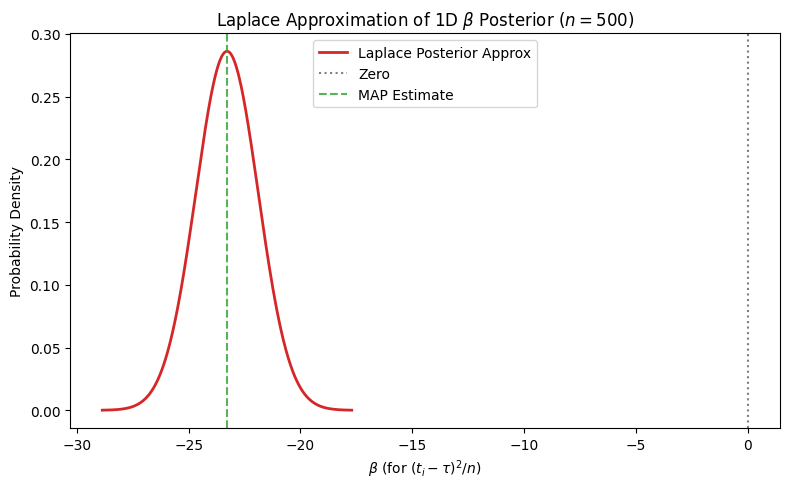

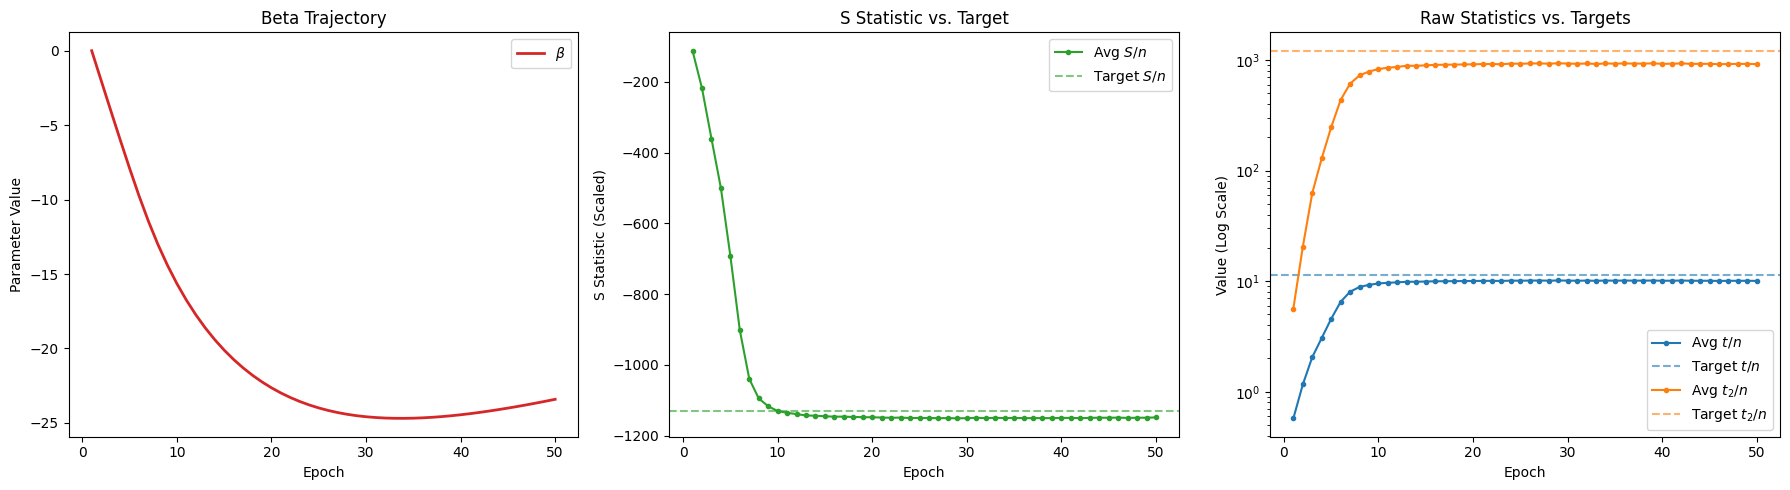

In [11]:
fitted_beta, posterior_var, graph_history, history, G_target_nx, tau, target_S_scaled = fit_watts_strogatz_1d()

target_tris_dict = nx.triangles(G_target_nx)
target_node_triangles = np.array(list(target_tris_dict.values()))
target_t_scaled = (np.sum(target_node_triangles) // 3) / G_target_nx.number_of_nodes()
target_t2_scaled = np.sum(target_node_triangles ** 2) / G_target_nx.number_of_nodes()

plot_posteriors_and_significance_1d(fitted_beta, posterior_var)
plot_optimization_history_1d(history, target_S_scaled, target_t_scaled, target_t2_scaled)

Generating Target Erdos-Renyi Graph...
Target Stats -> t/n: 0.53, t2/n: 4.75
Coupling Parameter -> tau (mean node triangles): 1.5780
Target Sufficient Statistic -> S/n: -0.23

Initializing starting graph G_init from the Target Graph...

Starting 1D MLE Optimization...
0.5
Sampling step 0/500000
Sampling step 100000/500000
Sampling step 200000/500000
Sampling step 300000/500000
Sampling step 400000/500000
Epoch 1/20 | Target S/n: -0.23, Avg S/n: 0.00 | Beta: -0.5000Target t/n: 0.53, Avg t/n: 0.54 | Target t2/n: 4.75, Avg t2/n: 5.13
Sampling step 0/500000
Sampling step 100000/500000
Sampling step 200000/500000
Sampling step 300000/500000
Sampling step 400000/500000
Epoch 2/20 | Target S/n: -0.23, Avg S/n: -0.04 | Beta: -0.9946Target t/n: 0.53, Avg t/n: 0.54 | Target t2/n: 4.75, Avg t2/n: 5.07
Sampling step 0/500000
Sampling step 100000/500000
Sampling step 200000/500000
Sampling step 300000/500000
Sampling step 400000/500000
Epoch 3/20 | Target S/n: -0.23, Avg S/n: -0.04 | Beta: -1.4884T

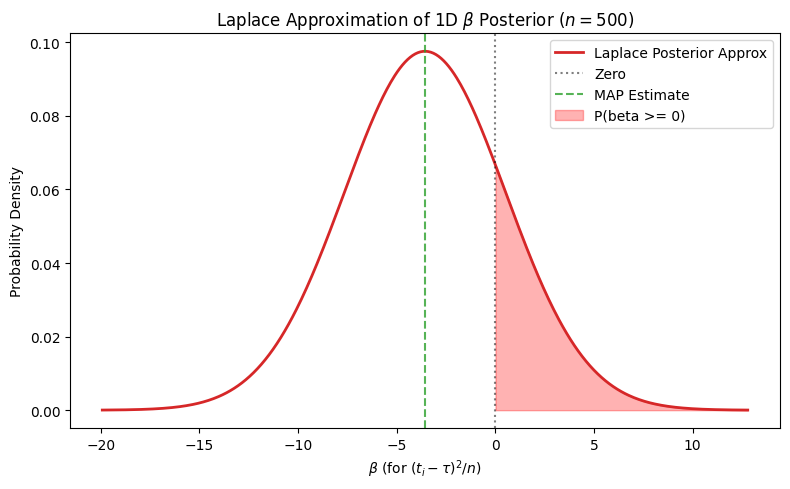

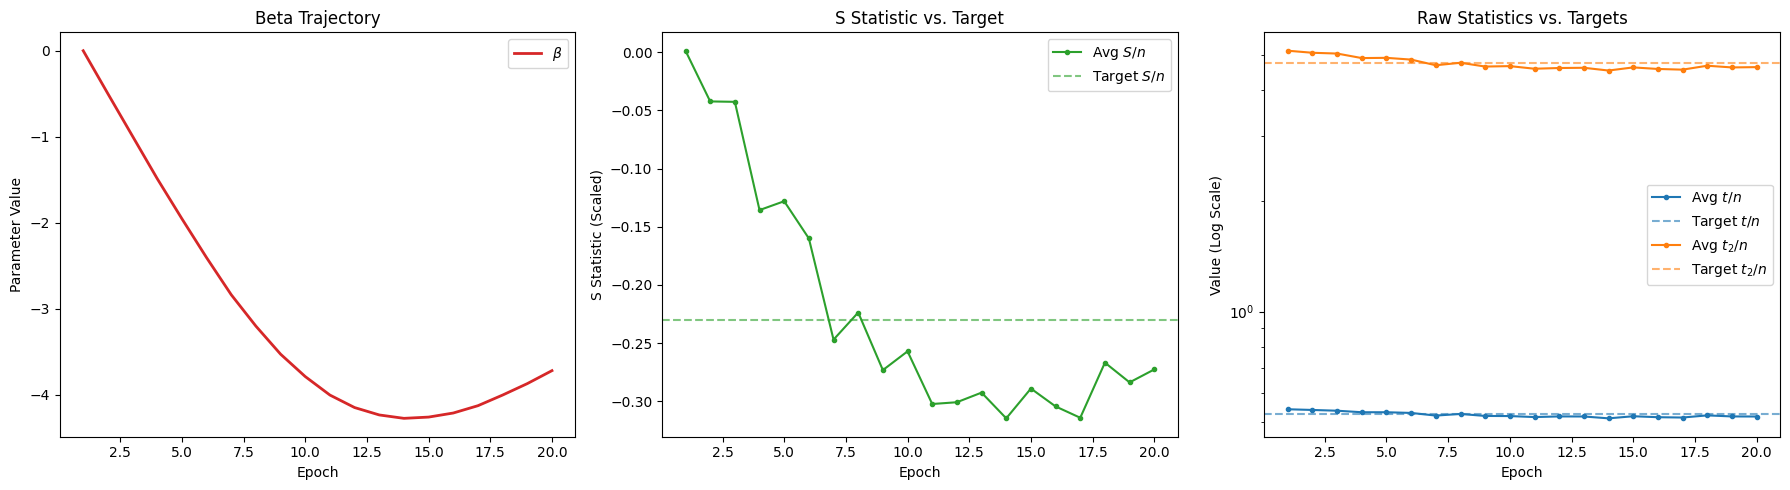

In [10]:
fitted_beta, posterior_var, graph_history, history, G_target_nx, tau, target_S_scaled = fit_erdos_renyi_1d()

target_tris_dict = nx.triangles(G_target_nx)
target_node_triangles = np.array(list(target_tris_dict.values()))
target_t_scaled = (np.sum(target_node_triangles) // 3) / G_target_nx.number_of_nodes()
target_t2_scaled = np.sum(target_node_triangles ** 2) / G_target_nx.number_of_nodes()

plot_posteriors_and_significance_1d(fitted_beta, posterior_var)
plot_optimization_history_1d(history, target_S_scaled, target_t_scaled, target_t2_scaled)

Starting Forward Sweep (Sparse -> Dense)...
-1.5 100000 -0.6323317555199871
-1.5 200000 -0.6190296521600138
-1.5 300000 -0.6300866204799882
-1.5 400000 -0.5993417564799897
-1.5 500000 -0.627295822720002
-1.5 600000 -0.6505279212799775
-1.5 700000 -0.6099871705600055
-1.5 800000 -0.5422673955199957
-1.5 900000 -0.6007171513599975
Beta=-1.50 | Converged in 1000000 steps | Avg S/n:      -0.59 | Time: 177.71s
-1.2586206896551724 100000 -0.6383500201599837
-1.2586206896551724 200000 -0.6281330576000039
-1.2586206896551724 300000 -0.5729364707199797
-1.2586206896551724 400000 -0.5932048883200078
-1.2586206896551724 500000 -0.5799768105599895
-1.2586206896551724 600000 -0.6277049967999966
-1.2586206896551724 700000 -0.6047262316799937
Beta=-1.26 | Converged in 800000  steps | Avg S/n:      -0.53 | Time: 137.25s
-1.0172413793103448 100000 -0.5863725516800015
-1.0172413793103448 200000 -0.5449751955199973
-1.0172413793103448 300000 -0.5969661433600069
Beta=-1.02 | Converged in 400000  steps | A

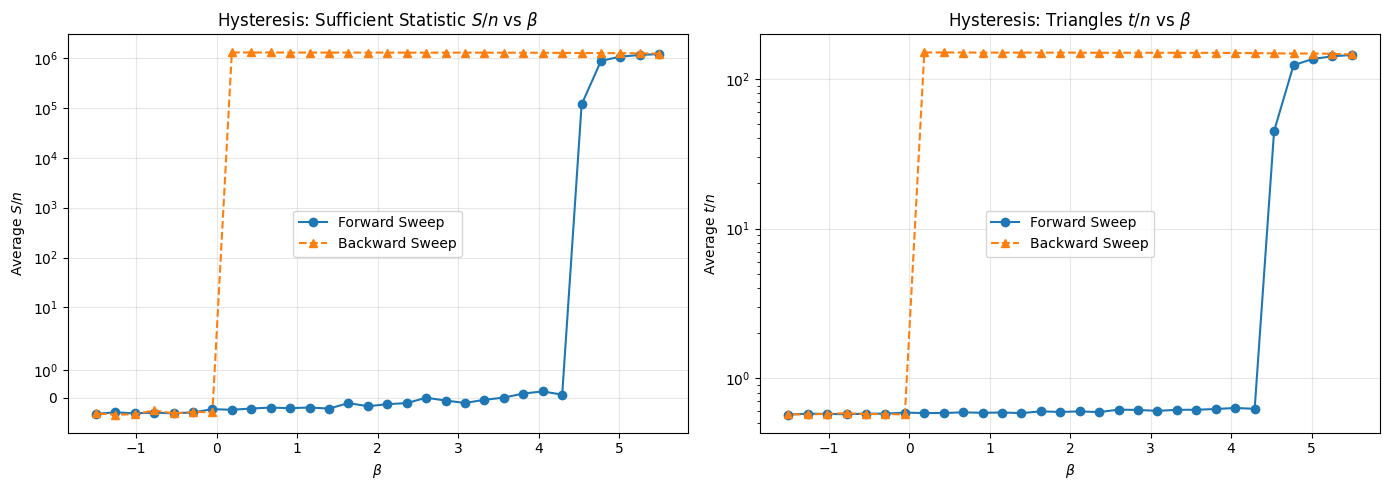

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import time

def mcmc_step_1d(G, t, t2, beta, tau, n, m):
    """Performs a single Metropolis-Hastings edge-swap step for the S/n distribution."""
    # 1. Select a random existing edge to remove
    while True:
        u_r, v_r = np.random.randint(0, n, 2)
        if u_r != v_r and G.has_edge(u_r, v_r): 
            break

    # 2. Select a random non-edge to add
    while True:
        u_a, v_a = np.random.randint(0, n, 2)
        if u_a != v_a and not G.has_edge(u_a, v_a): 
            break

    # Calculate deltas for removing (u_r, v_r)
    common_r = G.get_common_neighbors(u_r, v_r, m)
    delta_t2_r = G.get_delta_sum_sq_triangles(u_r, v_r, True, common_r)
    delta_t_r = -len(common_r)
    
    # Temporarily apply removal to accurately calculate addition deltas
    G.remove_edge(u_r, v_r, common_r)

    # Calculate deltas for adding (u_a, v_a)
    common_a = G.get_common_neighbors(u_a, v_a, m)
    delta_t2_a = G.get_delta_sum_sq_triangles(u_a, v_a, False, common_a)
    delta_t_a = len(common_a)

    # Aggregate deltas
    delta_t = delta_t_r + delta_t_a
    delta_t2 = delta_t2_r + delta_t2_a
    
    # Energy change: delta_S = delta_t2 - 2 * tau * delta_sum(t_i)
    # Since sum(t_i) = 3 * t, the change is delta_t2 - 6 * tau * delta_t
    delta_S = delta_t2 - 6 * tau * delta_t
    delta_energy = (beta * delta_S) / n
    
    # Metropolis-Hastings acceptance
    if np.log(np.random.uniform()) <= delta_energy:
        G.add_edge(u_a, v_a, common_a)
        t += delta_t
        t2 += delta_t2
    else:
        # Reject: revert the removal
        G.add_edge(u_r, v_r, common_r)
        
    return t, t2

def run_sweep_1d(b_vals, G, t, t2, tau, n, m, max_burn_in=1000000, window_size=100000, tol=1e-3, sample_its=100000):
    """Runs the MCMC sweep tracking S/n and t/n."""
    S_results = []
    t_results = []
    
    for beta in b_vals:
        start_time = time.time()
        
        # 1. Dynamic Burn-in Phase (Converging on S/n instead of t)
        prev_mean_S = -1
        current_S_sum = 0
        step = 0
        converged = False
        
        while step < max_burn_in and not converged:
            if step % window_size == 0 and step > 0:
                    print(beta, step, current_mean_S)
            for _ in range(window_size):
                t, t2 = mcmc_step_1d(G, t, t2, beta, tau, n, m)
                current_S = (t2 - 6 * tau * t) / n
                current_S_sum += current_S
                step += 1
            
            current_mean_S = current_S_sum / window_size
            if prev_mean_S != -1:
                # Use absolute difference because S/n approaches zero
                diff = abs(current_mean_S - prev_mean_S)
                
                # A tolerance of 0.01 to 0.05 is standard for absolute S/n variance
                if diff < 0.01: 
                    converged = True
                    
            prev_mean_S = current_mean_S
            current_S_sum = 0

        # 2. Sampling Phase (post-convergence)
        total_S = 0
        total_t = 0
        for _ in range(sample_its):
            t, t2 = mcmc_step_1d(G, t, t2, beta, tau, n, m)
            current_S = (t2 - 6 * tau * t) / n
            total_S += current_S
            total_t += (t / n)
            
        avg_S = total_S / sample_its
        avg_t = total_t / sample_its
        
        S_results.append(avg_S)
        t_results.append(avg_t)
        
        print(f"Beta={beta:5.2f} | Converged in {step:<7} steps | Avg S/n: {avg_S:10.2f} | Time: {time.time() - start_time:.2f}s")
        
    return S_results, t_results, t, t2

# ==========================================
# Initialization & Execution
# ==========================================
# Assume `init_custom_graph_from_nx` and `graphWithComplement` are defined in your environment

n = 500
m = 3000
p = (2 * m) / (n * (n - 1))

# Generate base graph
G_base_nx = nx.erdos_renyi_graph(n, p)
target_tris_dict = nx.triangles(G_base_nx)
target_node_triangles = np.array(list(target_tris_dict.values()))

# Initialize stats
t = np.sum(target_node_triangles) // 3
t2 = np.sum(target_node_triangles ** 2)
tau = np.sum(target_node_triangles) / n

# Initialize custom graph state
G = init_custom_graph_from_nx(G_base_nx)

# Define sweep range based on hysteresis bounds
b_vals = np.linspace(-1.5, 5.5, 30)

print("Starting Forward Sweep (Sparse -> Dense)...")
up_S, up_t, t, t2 = run_sweep_1d(b_vals, G, t, t2, tau, n, m)

print("\nStarting Backward Sweep (Dense -> Sparse)...")
# Must reverse array directly, do not use built-in reversed() to maintain array properties for plotting
down_b_vals = b_vals[::-1] 
down_S, down_t, t, t2 = run_sweep_1d(down_b_vals, G, t, t2, tau, n, m)

# ==========================================
# Plotting
# ==========================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot Sufficient Statistic (S/n)
ax1.set_title(r'Hysteresis: Sufficient Statistic $S/n$ vs $\beta$')
ax1.plot(b_vals, up_S, label='Forward Sweep', marker='o', color='#1f77b4', linestyle='-')
ax1.plot(down_b_vals, down_S, label='Backward Sweep', marker='^', color='#ff7f0e', linestyle='--')
ax1.set_xlabel(r'$\beta$')
ax1.set_ylabel(r'Average $S/n$')
ax1.set_yscale('symlog') # symlog handles large ranges crossing zero
ax1.grid(True, alpha=0.3)
ax1.legend()

# Plot Scaled Triangles (t/n)
ax2.set_title(r'Hysteresis: Triangles $t/n$ vs $\beta$')
ax2.plot(b_vals, up_t, label='Forward Sweep', marker='o', color='#1f77b4', linestyle='-')
ax2.plot(down_b_vals, down_t, label='Backward Sweep', marker='^', color='#ff7f0e', linestyle='--')
ax2.set_xlabel(r'$\beta$')
ax2.set_ylabel(r'Average $t/n$')
ax2.set_yscale('log')
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()